Dataset Preview:
   Year  Present_Price  Kms_Driven Fuel_Type Seller_Type Transmission  Owner  \
0  2015           5.59       27000    Petrol      Dealer       Manual      0   
1  2012           9.54       43000    Diesel      Dealer       Manual      0   
2  2018           8.00        6900    Petrol      Dealer       Manual      0   
3  2016           7.21       13000    Diesel      Dealer    Automatic      0   
4  2014           5.71       50000    Petrol      Dealer       Manual      1   

   Selling_Price  
0           3.35  
1           4.75  
2           7.25  
3           6.50  
4           2.80  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           10 non-null     int64  
 1   Present_Price  10 non-null     float64
 2   Kms_Driven     10 non-null     int64  
 3   Fuel_Type      10 non-null     object 
 4   Sel

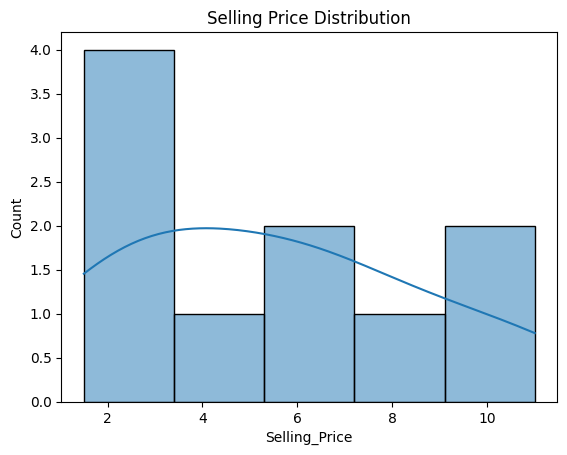

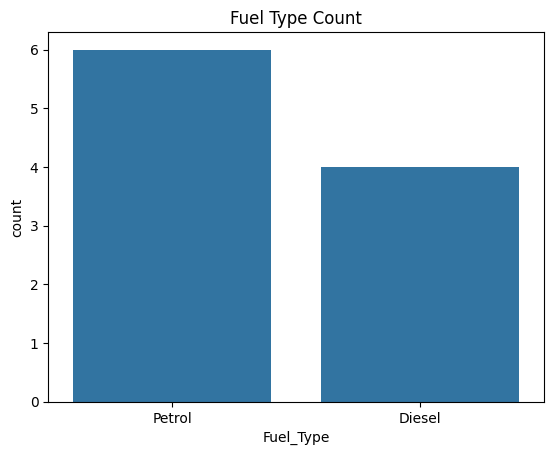

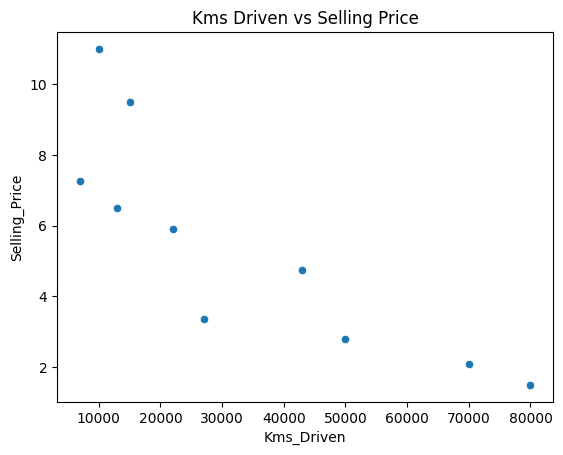

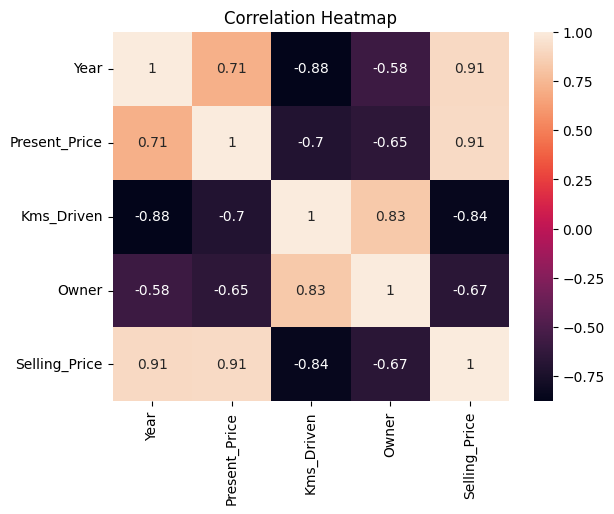


Model Performance:
MSE: 0.031575221141813256
R2 Score: 0.9880425198042837


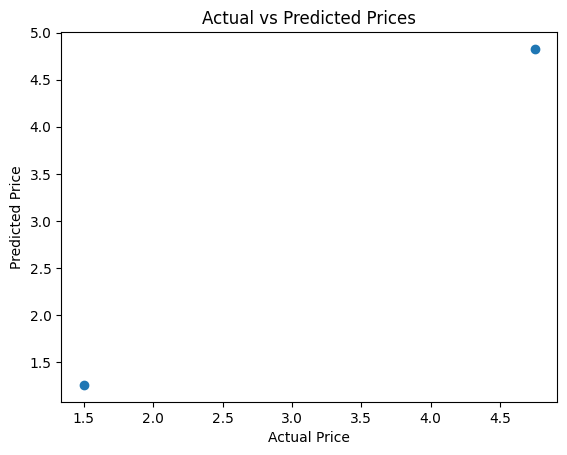

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

data = {
    "Year": [2015, 2012, 2018, 2016, 2014, 2019, 2017, 2013, 2011, 2020],
    "Present_Price": [5.59, 9.54, 8.0, 7.21, 5.71, 10.5, 6.8, 4.5, 3.9, 12.0],
    "Kms_Driven": [27000, 43000, 6900, 13000, 50000, 15000, 22000, 70000, 80000, 10000],
    "Fuel_Type": ["Petrol", "Diesel", "Petrol", "Diesel", "Petrol", "Diesel", "Petrol", "Petrol", "Diesel", "Petrol"],
    "Seller_Type": ["Dealer", "Dealer", "Dealer", "Dealer", "Dealer", "Dealer", "Dealer", "Individual", "Individual", "Dealer"],
    "Transmission": ["Manual", "Manual", "Manual", "Automatic", "Manual", "Automatic", "Manual", "Manual", "Manual", "Automatic"],
    "Owner": [0, 0, 0, 0, 1, 0, 0, 2, 1, 0],
    "Selling_Price": [3.35, 4.75, 7.25, 6.5, 2.8, 9.5, 5.9, 2.1, 1.5, 11.0]
}

df = pd.DataFrame(data)

print("Dataset Preview:")
print(df.head())


print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

plt.figure()
sns.histplot(df["Selling_Price"], kde=True)
plt.title("Selling Price Distribution")
plt.show()
plt.figure()
sns.countplot(x="Fuel_Type", data=df)
plt.title("Fuel Type Count")
plt.show()

plt.figure()
sns.scatterplot(x="Kms_Driven", y="Selling_Price", data=df)
plt.title("Kms Driven vs Selling Price")
plt.show()

plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("R2 Score:", r2)
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()